# Spotifake Baseline Classification Workflow

This notebook builds a simple end-to-end music genre classification baseline for the Spotifake project.

It covers:
- installing dependencies
- loading repository datasets
- cleaning and transforming features
- training a baseline classifier
- evaluating metrics and plots
- saving artifacts and running a sample prediction

Use it as the notebook version of the script-based workflow, with Colab-style step-by-step execution.

## 1. Install and Import Dependencies

This section installs any missing packages and imports the core libraries used throughout the notebook.

In [1]:
# Install notebook dependencies if needed
%pip install -q pandas numpy scikit-learn matplotlib seaborn joblib

import json
import os
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, label_binarize

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
print("Dependencies imported successfully.")


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Dependencies imported successfully.


## 1b. Dataset Download Controls

Use this cell to download genre clips from the internet with simple editable variables. Set the values and run the cell.

In [ ]:
import os
import subprocess
import sys
from pathlib import Path

# Edit these values, then run the cell.
out_dir = "datasets/genre18_audio"
samples = 100
clip_duration = 30
clip_position = "middle"  # "middle" (default) or "start"
min_video_duration = 90  # 1.5 minutes
max_video_duration = 600  # 10 minutes
skip_livestreams = True
duplicate_mode = "1"  # 1 = skip duplicates, 2 = allow duplicates
force_redownload = False  # force redownload of videos even if they already exist in the output directory
verbose = True
prune_non_target = True  # remove folders for genres outside the 11 allowed classes

# Parallel + strict filtering controls
workers = 10  # parallel downloads per genre
strict_title_match = False
min_view_count = 50000   # 0 disables this filter
max_age_days = 0        # 0 disables this filter

# Cookies + rate-limiting (helps avoid YouTube anti-bot blocks)
# Set one of these: cookies_from_browser='chrome' to use your browser session,
# or cookies_path='C:/path/to/cookies.txt' for an exported cookies file.
cookies_from_browser = 'chrome'
cookies_path = None
sleep_interval = 1.5
max_sleep_interval = 3.0

# Restricted taxonomy (11 genres)
genres = [
    "Pop",
    "Rock",
    "Hip-Hop / Rap",
    "R&B / Soul",
    "Electronic / EDM",
    "Country",
    "Jazz",
    "Blues",
    "Classical",
    "Reggae",
    "Latin",
]

log_file = Path(out_dir) / "download_run.log"
log_file.parent.mkdir(parents=True, exist_ok=True)

command = [
    sys.executable,
    "download_genre_dataset.py",
    "--out-dir", out_dir,
    "--samples", str(samples),
    "--clip-duration", str(clip_duration),
    "--clip-position", clip_position,
    "--min-video-duration", str(min_video_duration),
    "--max-video-duration", str(max_video_duration),
    "--duplicate-mode", duplicate_mode,
    "--workers", str(max(1, int(workers))),
    "--min-view-count", str(max(0, int(min_view_count))),
    "--max-age-days", str(max(0, int(max_age_days))),
    "--genres", *genres,
    "--sleep-interval", str(sleep_interval),
    "--max-sleep-interval", str(max_sleep_interval),
]

if strict_title_match:
    command.append("--strict-title-match")
if prune_non_target:
    command.append("--prune-non-target")
else:
    command.append("--keep-non-target")
if skip_livestreams:
    command.append("--skip-livestreams")
else:
    command.append("--allow-livestreams")
if force_redownload:
    command.append("--force-redownload")
if cookies_from_browser:
    command.extend(["--cookies-from-browser", cookies_from_browser])
elif cookies_path:
    command.extend(["--cookies-path", str(cookies_path)])
if verbose:
    command.append("--verbose")

print("Running downloader with these settings:")
print(f"  out_dir = {out_dir}")
print(f"  samples = {samples}")
print(f"  clip_duration = {clip_duration}")
print(f"  clip_position = {clip_position}")
code
python
# Optional: use an exported cookies.txt file from your browser if browser export fails
# Set this to the full path of a Netscape-format cookies file you exported (e.g. from an extension)
# Example: cookies_path = 'C:/Users/jacky/Downloads/chrome_cookies.txt'
cookies_path = None  # <-- set your path here (or leave None)
from pathlib import Path
if cookies_path:
    p = Path(cookies_path)
    if p.exists():
        print(f'Using cookies file: {p}')
    else:
        print(f'WARNING: cookies file not found: {p}')
else:
    print('No cookies file set. To reduce YouTube blocking without cookies, lower `workers` and increase `sleep_interval`.')
print(f"  genres = {genres}")
print(f"  prune_non_target = {prune_non_target}")
print(f"  workers = {workers}")
print(f"  strict_title_match = {strict_title_match}")
print(f"  min_view_count = {min_view_count}")
print(f"  max_age_days = {max_age_days}")
print(f"  min_video_duration = {min_video_duration}")
print(f"  max_video_duration = {max_video_duration}")
print(f"  skip_livestreams = {skip_livestreams}")
print(f"  duplicate_mode = {duplicate_mode}")
print(f"  force_redownload = {force_redownload}")
print(f"  cookies_from_browser = {cookies_from_browser}")
print(f"  cookies_path = {cookies_path}")
print(f"  sleep_interval = {sleep_interval}")
print(f"  max_sleep_interval = {max_sleep_interval}")
print(f"  log_file = {log_file}")
print("Command:")
print(" ".join([p for p in command if p]))
print("\nStreaming output to the notebook and to the log file...\n")

env = os.environ.copy()
env["PYTHONUNBUFFERED"] = "1"

with open(log_file, "w", encoding="utf-8") as log_handle:
    process = subprocess.Popen(
        command,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
        env=env,
    )

    assert process.stdout is not None
    for line in process.stdout:
        print(line, end="")
        log_handle.write(line)
        log_handle.flush()

    process.wait()
    print(f"\nExit code: {process.returncode}")

print(f"\nLog saved to: {log_file}")

Running downloader with these settings:
  out_dir = datasets/genre18_audio
  samples = 100
  clip_duration = 30
  clip_position = middle
  genres = ['Pop', 'Rock', 'Hip-Hop / Rap', 'R&B / Soul', 'Electronic / EDM', 'Country', 'Jazz', 'Blues', 'Classical', 'Reggae', 'Latin']
  prune_non_target = True
  workers = 10
  strict_title_match = False
  min_view_count = 50000
  max_age_days = 0
  min_video_duration = 90
  max_video_duration = 600
  skip_livestreams = True
  duplicate_mode = 1
  force_redownload = False
  cookies_from_browser = chrome
  cookies_path = None
  sleep_interval = 1.5
  max_sleep_interval = 3.0
  log_file = datasets\genre18_audio\download_run.log
Command:
c:\Users\jacky\OneDrive\Desktop\New folder\.venv\Scripts\python.exe download_genre_dataset.py --out-dir datasets/genre18_audio --samples 100 --clip-duration 30 --clip-position middle --min-video-duration 90 --max-video-duration 600 --duplicate-mode 1 --workers 10 --min-view-count 50000 --max-age-days 0 --genres Pop R

## 2. Load Project Data from Repository

This section loads a dataset from the repository, inspects its shape and column types, and shows sample rows.

In [2]:
# Restrict training to the 11 selected genres
TARGET_GENRES = [
    "Pop",
    "Rock",
    "Hip-Hop / Rap",
    "R&B / Soul",
    "Electronic / EDM",
    "Country",
    "Jazz",
    "Blues",
    "Classical",
    "Reggae",
    "Latin",
]

# Locate a repository CSV with labels and features
candidate_files = [
    Path("datasets/genre18_audio/features.csv"),
    Path("features.csv"),
    Path("datasets/genre18/features_18.csv"),
    Path("gtzan_data/Data/features_30_sec.csv"),
    Path("gtzan_data/Data/features_3_sec.csv"),
]


dataset_path = None
df = None

for path in candidate_files:
    if not path.exists():
        continue
    candidate_df = pd.read_csv(path)
    candidate_label = "genre" if "genre" in candidate_df.columns else ("label" if "label" in candidate_df.columns else None)
    if candidate_label is None:
        print(f"Skipping {path}: no genre/label column")
        continue

    # Keep only the 11 target genres if this file contains broader taxonomies.
    filtered_df = candidate_df[candidate_df[candidate_label].astype(str).isin(TARGET_GENRES)].copy()
    removed = len(candidate_df) - len(filtered_df)
    if removed > 0:
        print(f"Filtered out {removed} row(s) not in the 11 target genres from {path}")

    unique_labels = filtered_df[candidate_label].astype(str).nunique()
    if unique_labels < len(TARGET_GENRES):
        print(f"Skipping {path}: only {unique_labels} target label(s), need {len(TARGET_GENRES)}")
        continue

    dataset_path = path
    df = filtered_df
    print(f"Loading dataset from: {dataset_path}")
    print(f"Shape after 11-genre filter: {df.shape}")
    break

if df is None:
    print("No repository CSV with all 11 target genres was found, so this notebook is generating an 11-class synthetic fallback dataset.")
    print("Checked paths:")
    for path in candidate_files:
        print(f"  {path}: {'FOUND' if path.exists() else 'missing'}")
    print(f"Current working directory: {Path.cwd()}")
    X_synth, y_synth = make_classification(
        n_samples=1800,
        n_features=18,
        n_informative=8,
        n_redundant=4,
        n_classes=len(TARGET_GENRES),
        random_state=42,
    )
    df = pd.DataFrame(X_synth, columns=[f"feature_{i+1}" for i in range(X_synth.shape[1])])
    df["genre"] = pd.Series(y_synth).map({i: label for i, label in enumerate(TARGET_GENRES)})
    dataset_path = Path("synthetic_fallback_dataset")
    print(f"Synthetic dataset shape: {df.shape}")

# Show sample data and types
display(df.head())
print("\nColumn types:")
display(df.dtypes.to_frame(name="dtype"))

label_column = "genre" if "genre" in df.columns else ("label" if "label" in df.columns else None)
if label_column is None:
    raise ValueError('Dataset must contain a "genre" or "label" column')

print(f"\nUsing label column: {label_column}")
print("\nLabel distribution:")
display(df[label_column].value_counts().to_frame(name="count"))

Filtered out 6000 row(s) not in the 11 target genres from datasets\genre18_audio\features.csv
Skipping datasets\genre18_audio\features.csv: only 8 target label(s), need 11
Filtered out 5 row(s) not in the 11 target genres from features.csv
Skipping features.csv: only 0 target label(s), need 11
Skipping datasets\genre18\features_18.csv: only 1 target label(s), need 11
Filtered out 1000 row(s) not in the 11 target genres from gtzan_data\Data\features_30_sec.csv
Skipping gtzan_data\Data\features_30_sec.csv: only 0 target label(s), need 11
Filtered out 9990 row(s) not in the 11 target genres from gtzan_data\Data\features_3_sec.csv
Skipping gtzan_data\Data\features_3_sec.csv: only 0 target label(s), need 11
No repository CSV with all 11 target genres was found, so this notebook is generating an 11-class synthetic fallback dataset.
Checked paths:
  datasets\genre18_audio\features.csv: FOUND
  features.csv: FOUND
  datasets\genre18\features_18.csv: FOUND
  gtzan_data\Data\features_30_sec.csv:

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,genre
0,0.657546,-0.825700,-0.889370,-1.033939,-1.412900,-0.002024,3.017448,0.621898,-1.220343,3.767208,-1.542464,-1.271618,1.528285,-0.922847,0.626356,0.481593,3.310423,2.827705,R&B / Soul
1,-0.286554,1.161113,0.044667,1.500932,0.219219,2.376825,-0.258316,0.112964,-0.124693,-1.207891,0.424916,3.954653,0.709498,-0.027452,0.914209,0.018570,-2.675988,0.393880,Pop
2,0.962682,-1.083292,-0.320739,-0.719622,0.760160,4.307647,2.025894,-2.348338,0.831384,-1.159741,1.413712,2.181915,2.223474,-0.366770,-0.300687,-0.543559,0.613406,1.685596,Country
3,-0.999417,0.404903,0.508594,2.507118,-0.479146,-0.486234,0.770026,1.924948,0.704017,3.535423,-0.179352,-1.056417,-0.680336,-1.106465,-1.072560,-0.979448,-1.102323,1.463411,Jazz
4,-2.179627,-2.256749,0.673261,0.425826,1.017763,-0.774322,-1.211496,-2.543999,-0.538862,-1.040743,-0.729614,-2.268919,-2.660948,1.341078,1.548315,-0.792168,-0.354278,-1.384218,Classical



Column types:


,dtype
feature_1,float64
feature_2,float64
feature_3,float64
feature_4,float64
feature_5,float64
feature_6,float64
feature_7,float64
feature_8,float64
feature_9,float64
feature_10,float64



Using label column: genre

Label distribution:


,count
genre,
Country,166
Blues,166
Pop,165
Classical,165
Reggae,165
Rock,164
Jazz,163
Latin,163
R&B / Soul,162


## 3. Clean and Transform Features

This section prepares the feature matrix, handles missing values, and builds preprocessing steps for numeric and categorical columns.

In [25]:
# Split features and label
feature_df = df.copy()
if "filename" in feature_df.columns:
    feature_df = feature_df.drop(columns=["filename"])

# Remove exact duplicate rows before training so repeated clips do not inflate performance.
before_dedup = len(feature_df)
feature_df = feature_df.drop_duplicates().reset_index(drop=True)
after_dedup = len(feature_df)
print(f"Removed {before_dedup - after_dedup} duplicate row(s) before splitting.")

X_raw = feature_df.drop(columns=[label_column])
y_raw = feature_df[label_column].astype(str)

# Identify feature types
numeric_features = X_raw.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = [col for col in X_raw.columns if col not in numeric_features]

print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",
)

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)
classes_ = label_encoder.classes_

# Group by source track so near-duplicate clips from the same song stay in one split.
if "file" in feature_df.columns:
    group_source = feature_df["file"].astype(str)
elif "filename" in feature_df.columns:
    group_source = feature_df["filename"].astype(str)
else:
    group_source = pd.Series(feature_df.index.astype(str), index=feature_df.index)

groups = group_source.str.replace(r"_(\d+)\.mp3$", ".mp3", regex=True)

from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_raw, y, groups=groups))

X_train_raw = X_raw.iloc[train_idx].copy()
X_test_raw = X_raw.iloc[test_idx].copy()
y_train = y[train_idx]
y_test = y[test_idx]

print(f"Train shape: {X_train_raw.shape}")
print(f"Test shape: {X_test_raw.shape}")
print(f"Classes: {list(classes_)}")
print(f"Train groups: {groups.iloc[train_idx].nunique()}")
print(f"Test groups: {groups.iloc[test_idx].nunique()}")

Removed 0 duplicate row(s) before splitting.
Numeric features: 69
Categorical features: 1
Train shape: (7946, 70)
Test shape: (1987, 70)
Classes: ['Afrobeats', 'Anime / Vocaloid', 'Blues', 'Classical', 'Country', 'Electronic Dance Music (EDM)', 'Folk', 'Funk', 'Hip-Hop / Rap', 'Indie / Alternative', 'J-Pop', 'Jazz', 'K-Pop', 'Latin Music', 'Metal', 'Pop', 'R&B (Rhythm and Blues)', 'Reggae', 'Rock', 'Soul']
Train groups: 7946
Test groups: 1987


## 4. Build a Baseline Classification Model

This section defines a simple, reproducible scikit-learn baseline model.

In [21]:
# Baseline model: logistic regression inside a preprocessing pipeline
baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                random_state=42,
                solver="lbfgs",
            ),
        ),
    ]
)

baseline_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3I

## 5. Train, Compare, and Select the Best Model

This section benchmarks multiple models with cross-validation, then selects the best performer for final evaluation.

In [26]:
# Compare multiple models and pick the best one
from sklearn.base import clone
from sklearn.model_selection import GroupKFold, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
import time
import warnings

# Suppress noisy estimator warnings that do not affect training correctness.
warnings.filterwarnings(
    "ignore",
    message="X does not have valid feature names, but LGBMClassifier was fitted with feature names",
)

# Optional boosted models
LGBMClassifier = None
XGBClassifier = None
CATBoostClassifier = None

try:
    from lightgbm import LGBMClassifier
except Exception as e:
    print(f"LightGBM unavailable: {e}")

try:
    from xgboost import XGBClassifier
except Exception as e:
    print(f"XGBoost unavailable: {e}")

try:
    from catboost import CatBoostClassifier as CATBoostClassifier
except Exception as e:
    print(f"CatBoost unavailable: {e}")

train_groups = groups.iloc[train_idx]
unique_train_groups = train_groups.nunique()
cv_folds = min(5, unique_train_groups) if len(np.unique(y_train)) > 1 else 2
cv_folds = max(cv_folds, 2)

if unique_train_groups >= cv_folds:
    cv = GroupKFold(n_splits=cv_folds)
    cv_mode = "group"
else:
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
    cv_mode = "stratified"

print(f"Using {cv_mode} cross-validation with {cv_folds} fold(s).")

candidate_models = {
    "Logistic Regression": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "classifier",
                LogisticRegression(
                    max_iter=2000,
                    random_state=42,
                    solver="lbfgs",
                    C=0.5,
                ),
            ),
        ]
    ),
    "Random Forest": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "classifier",
                RandomForestClassifier(
                    n_estimators=250,
                    max_depth=18,
                    min_samples_leaf=4,
                    min_samples_split=8,
                    max_features="sqrt",
                    random_state=42,
                    n_jobs=-1,
                ),
            ),
        ]
    ),
    "KNN": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "classifier",
                KNeighborsClassifier(n_neighbors=25, weights="distance"),
            ),
        ]
    ),
}

if LGBMClassifier is not None:
    candidate_models["LightGBM"] = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "classifier",
                LGBMClassifier(
                    n_estimators=180,
                    learning_rate=0.03,
                    num_leaves=31,
                    max_depth=8,
                    min_child_samples=50,
                    subsample=0.8,
                    subsample_freq=1,
                    colsample_bytree=0.8,
                    reg_alpha=1.0,
                    reg_lambda=1.0,
                    random_state=42,
                    objective="multiclass",
                    n_jobs=-1,
                    force_col_wise=True,
                    verbosity=-1,
                ),
            ),
        ]
    )

if XGBClassifier is not None:
    candidate_models["XGBoost"] = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "classifier",
                XGBClassifier(
                    n_estimators=250,
                    learning_rate=0.05,
                    max_depth=6,
                    min_child_weight=3,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    reg_alpha=1.0,
                    reg_lambda=1.0,
                    random_state=42,
                    n_jobs=-1,
                    tree_method="hist",
                    objective="multi:softprob",
                    eval_metric="mlogloss",
                ),
            ),
        ]
    )
elif CATBoostClassifier is not None:
    candidate_models["CatBoost"] = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "classifier",
                CATBoostClassifier(
                    iterations=250,
                    learning_rate=0.05,
                    depth=6,
                    l2_leaf_reg=6.0,
                    random_seed=42,
                    verbose=False,
                ),
            ),
        ]
    )

results = []
fitted_models = {}

for model_name, model in candidate_models.items():
    print(f"\nTraining: {model_name}")
    start = time.perf_counter()

    try:
        if cv_mode == "group":
            cv_scores = cross_val_score(
                model,
                X_train_raw,
                y_train,
                cv=cv,
                scoring="f1_macro",
                groups=train_groups,
            )
        else:
            cv_scores = cross_val_score(model, X_train_raw, y_train, cv=cv, scoring="f1_macro")
        cv_mean = float(cv_scores.mean())
        cv_std = float(cv_scores.std())
    except Exception as e:
        print(f"  CV failed for {model_name}: {e}")
        cv_mean = np.nan
        cv_std = np.nan

    fitted = clone(model)
    fitted.fit(X_train_raw, y_train)
    fitted_models[model_name] = fitted

    train_pred = fitted.predict(X_train_raw)
    test_pred = fitted.predict(X_test_raw)

    train_fit_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)
    test_f1_weighted = f1_score(y_test, test_pred, average="weighted", zero_division=0)
    test_f1_macro = f1_score(y_test, test_pred, average="macro", zero_division=0)
    generalization_gap = train_fit_acc - test_acc

    elapsed = time.perf_counter() - start
    results.append(
        {
            "model": model_name,
            "cv_accuracy_mean": cv_mean,
            "cv_accuracy_std": cv_std,
            "train_fit_accuracy": train_fit_acc,
            "test_accuracy": test_acc,
            "generalization_gap": generalization_gap,
            "test_f1_weighted": test_f1_weighted,
            "test_f1_macro": test_f1_macro,
            "fit_seconds": elapsed,
        }
    )

leaderboard = pd.DataFrame(results).sort_values(
    by=["test_f1_macro", "test_accuracy"], ascending=False
).reset_index(drop=True)

print("\nModel leaderboard (sorted by macro-F1 then accuracy):")
display(leaderboard)

best_model_name = leaderboard.loc[0, "model"]
baseline_model = fitted_models[best_model_name]

print(f"\nSelected best model: {best_model_name}")

train_predictions = baseline_model.predict(X_train_raw)
test_predictions = baseline_model.predict(X_test_raw)

train_accuracy = accuracy_score(y_train, train_predictions)
test_accuracy = accuracy_score(y_test, test_predictions)

print(f"Training fit accuracy: {train_accuracy:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")
print("Training fit accuracy is expected to be much higher than test accuracy when the model overfits.")

Using group cross-validation with 5 fold(s).

Training: Logistic Regression

Training: Random Forest

Training: KNN

Training: LightGBM

Training: XGBoost

Model leaderboard (sorted by macro-F1 then accuracy):


,model,cv_accuracy_mean,cv_accuracy_std,train_fit_accuracy,test_accuracy,generalization_gap,test_f1_weighted,test_f1_macro,fit_seconds
0,XGBoost,0.361137,0.011232,0.997483,0.392552,0.604931,0.389571,0.390127,359.353551
1,LightGBM,0.360815,0.016509,0.989303,0.386009,0.603294,0.382307,0.381966,47.241654
2,Logistic Regression,0.309169,0.013857,0.511075,0.330649,0.180426,0.321249,0.322215,17.237993
3,KNN,0.279355,0.009338,1.000000,0.301459,0.698541,0.296272,0.295228,8.649122
4,Random Forest,0.168901,0.007335,0.286811,0.185707,0.101104,0.153981,0.156171,4.593716



Selected best model: XGBoost
Training fit accuracy: 0.9975
Test accuracy: 0.3926
Training fit accuracy is expected to be much higher than test accuracy when the model overfits.


## 6. Evaluate Metrics and Plot Results

This section computes classification metrics and draws confusion-matrix and ROC visualizations.

Accuracy:  0.3926
Precision: 0.3928
Recall:    0.3926
F1-score:  0.3896

Classification report:

                              precision    recall  f1-score   support

                   Afrobeats       0.39      0.49      0.43       105
            Anime / Vocaloid       0.39      0.33      0.36       102
                       Blues       0.45      0.43      0.44       100
                   Classical       0.58      0.62      0.60        97
                     Country       0.37      0.47      0.41        96
Electronic Dance Music (EDM)       0.44      0.41      0.43        94
                        Folk       0.46      0.43      0.44       118
                        Funk       0.29      0.39      0.33        77
               Hip-Hop / Rap       0.38      0.37      0.38       110
         Indie / Alternative       0.42      0.35      0.39       102
                       J-Pop       0.26      0.21      0.23        99
                        Jazz       0.43      0.52      0.47   

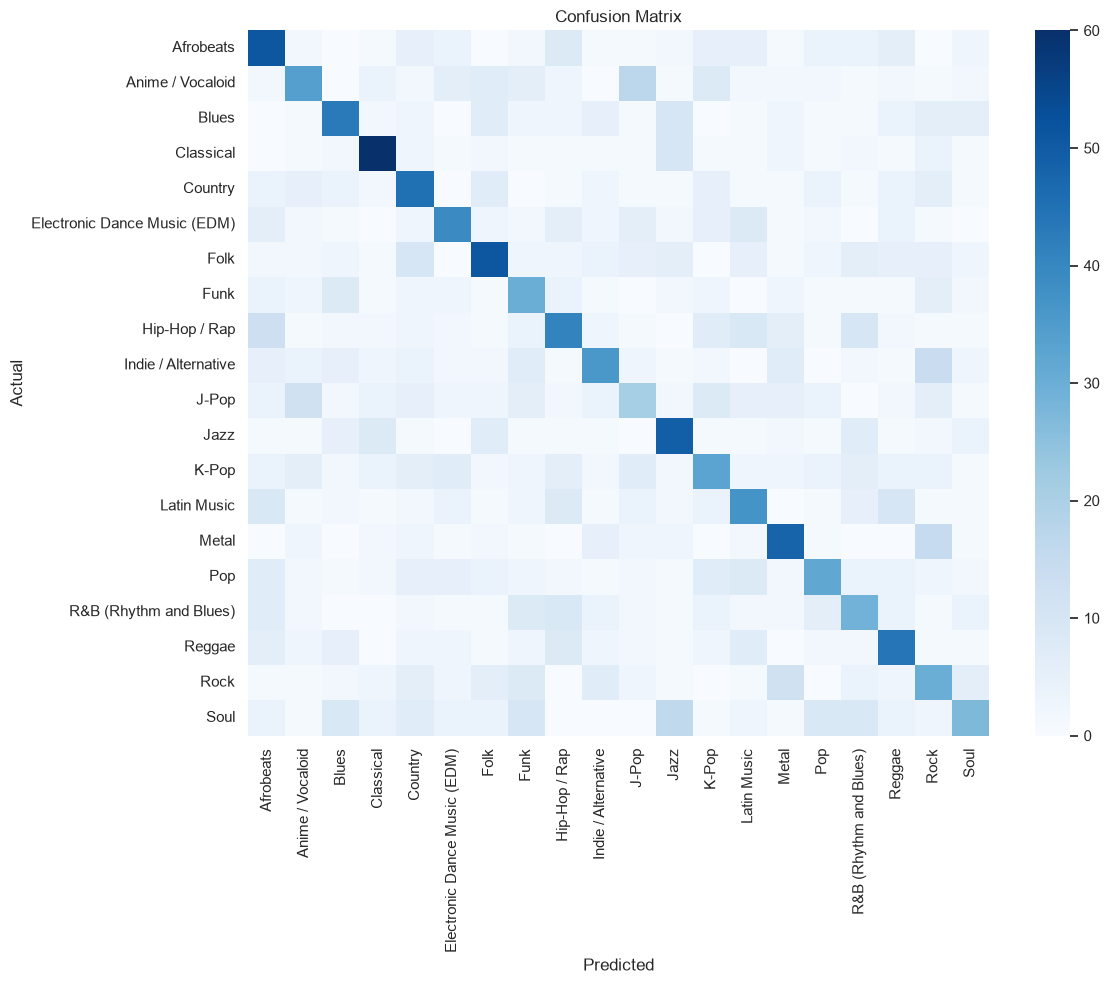

ROC-AUC (macro OVR): 0.8567


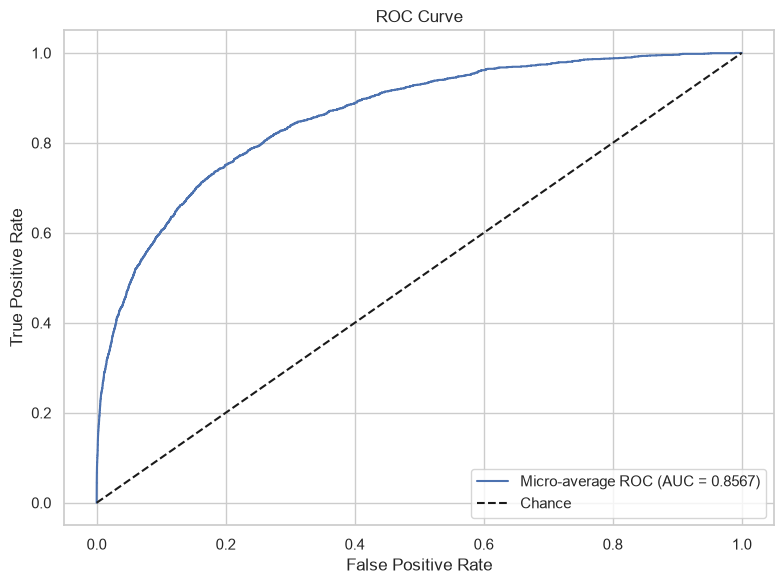

In [23]:
# Detailed evaluation metrics
precision = precision_score(y_test, test_predictions, average="weighted", zero_division=0)
recall = recall_score(y_test, test_predictions, average="weighted", zero_division=0)
f1 = f1_score(y_test, test_predictions, average="weighted", zero_division=0)
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print("\nClassification report:\n")
print(classification_report(
    y_test,
    test_predictions,
    labels=np.arange(len(classes_)),
    target_names=list(classes_),
    zero_division=0,
))

# Confusion matrix
cm = confusion_matrix(y_test, test_predictions, labels=np.arange(len(classes_)))
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=False, cmap="Blues", xticklabels=classes_, yticklabels=classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# ROC-AUC and ROC curve(s)
if hasattr(baseline_model, "predict_proba") and len(classes_) > 1:
    y_proba = baseline_model.predict_proba(X_test_raw)
    y_test_bin = label_binarize(y_test, classes=np.arange(len(classes_)))
    roc_auc = roc_auc_score(y_test_bin, y_proba, average="macro", multi_class="ovr")
    print(f"ROC-AUC (macro OVR): {roc_auc:.4f}")

    # Plot micro-average ROC curve
    fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_proba.ravel())
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f"Micro-average ROC (AUC = {roc_auc:.4f})")
    plt.plot([0, 1], [0, 1], "k--", label="Chance")
    plt.title("ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

## 7. Save Model Artifacts and Inference Example

This section saves the fitted model and demonstrates inference on a sample input row.

In [24]:
# Save the trained pipeline and label encoder
artifacts_dir = Path("BackendAI/models")
artifacts_dir.mkdir(parents=True, exist_ok=True)
model_path = artifacts_dir / "spotifake_baseline_pipeline.joblib"
joblib.dump(
    {
        "model": baseline_model,
        "label_encoder": label_encoder,
        "feature_columns": X_raw.columns.tolist(),
        "target_column": label_column,
    },
    model_path,
)
print(f"Saved model artifact to: {model_path}")

# Inference example using the first test row
sample_row = X_test_raw.iloc[[0]]
predicted_class = baseline_model.predict(sample_row)[0]
predicted_label = label_encoder.inverse_transform([predicted_class])[0]
predicted_proba = baseline_model.predict_proba(sample_row)[0]

print("\nSample inference:")
print(f"Predicted genre: {predicted_label}")
print("Top class probabilities:")
for idx in np.argsort(predicted_proba)[::-1][:5]:
    print(f"  {label_encoder.inverse_transform([idx])[0]}: {predicted_proba[idx]:.4f}")

Saved model artifact to: BackendAI\models\spotifake_baseline_pipeline.joblib

Sample inference:
Predicted genre: Afrobeats
Top class probabilities:
  Afrobeats: 0.3849
  R&B (Rhythm and Blues): 0.1315
  Hip-Hop / Rap: 0.1198
  Funk: 0.0748
  Pop: 0.0652
